In [ ]:
import pandas as pd

# قنات الجديد لعام 2022راءة ملف البيا
df = pd.read_csv('heart_2022_with_nans.csv')

print("="*50)
print("Initial Data Dimensions Check:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("="*50)

print("\nMissing Values Count per Column (First 15 columns):")
print(df.isnull().sum().head(15))

print("\nFirst 3 rows of the dataset:")
print(df.head(3))

Initial Data Dimensions Check:
Number of rows: 445132
Number of columns: 40

Missing Values Count per Column (First 15 columns):
State                     0
Sex                       0
GeneralHealth          1198
PhysicalHealthDays    10927
MentalHealthDays       9067
LastCheckupTime        8308
PhysicalActivities     1093
SleepHours             5453
RemovedTeeth          11360
HadHeartAttack         3065
HadAngina              4405
HadStroke              1557
HadAsthma              1773
HadSkinCancer          3143
HadCOPD                2219
dtype: int64

First 3 rows of the dataset:
     State     Sex GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
0  Alabama  Female     Very good                 0.0               0.0   
1  Alabama  Female     Excellent                 0.0               0.0   
2  Alabama  Female     Very good                 2.0               3.0   

                                     LastCheckupTime PhysicalActivities  \
0  Within past year (anytime less th

In [ ]:
import pandas as pd

# 1. حذف الصفوف المفقودة في العمود المستهدف فقط
df = df.dropna(subset=['HadHeartAttack'])

# 2. فصل الأعمدة الرقمية والتصنيفية لمعالجة القيم المفقودة
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# تعويض الأعمدة الرقمية بالـ Median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# تعويض الأعمدة التصنيفية بالـ Mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("="*50)
print("Data Cleaning & Imputation Check:")
print(f"Remaining Missing Values Count: {df.isnull().sum().sum()}")
print(f"Data Dimensions after cleaning: {df.shape}")
print("="*50)

Data Cleaning & Imputation Check:
Remaining Missing Values Count: 0
Data Dimensions after cleaning: (442067, 40)


In [ ]:
# ابتكار ميزة جديدة: High_Risk_Lifestyle
df['High_Risk_Lifestyle'] = ((df['BMI'] > 25) & (df['SleepHours'] < 6)).astype(int)

print("="*50)
print("Feature Engineering Completed:")
print(df['High_Risk_Lifestyle'].value_counts())
print(f"New Data Dimensions: {df.shape}")
print("="*50)

Feature Engineering Completed:
High_Risk_Lifestyle
0    405704
1     36363
Name: count, dtype: int64
New Data Dimensions: (442067, 41)


/tmp/ipykernel_674/494047259.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HadHeartAttack', data=df, palette='Set2')


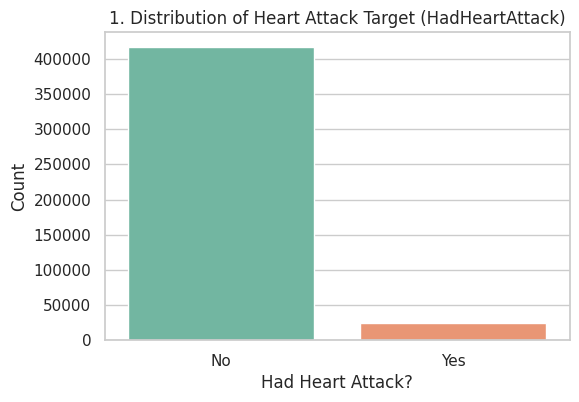

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Distribution of Heart Attacks
plt.figure(figsize=(6, 4))
sns.countplot(x='HadHeartAttack', data=df, palette='Set2')
plt.title('1. Distribution of Heart Attack Target (HadHeartAttack)')
plt.xlabel('Had Heart Attack?')
plt.ylabel('Count')
plt.show()



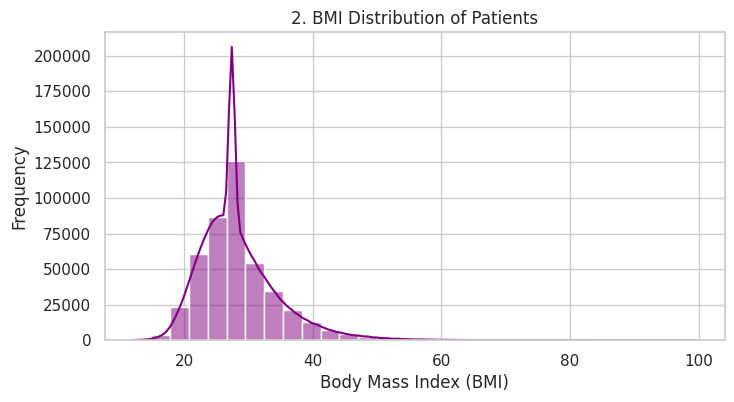

In [ ]:
# 2. BMI Distribution
plt.figure(figsize=(8, 4))
sns.histplot(x='BMI', data=df, bins=30, kde=True, color='purple')
plt.title('2. BMI Distribution of Patients')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Frequency')
plt.show()

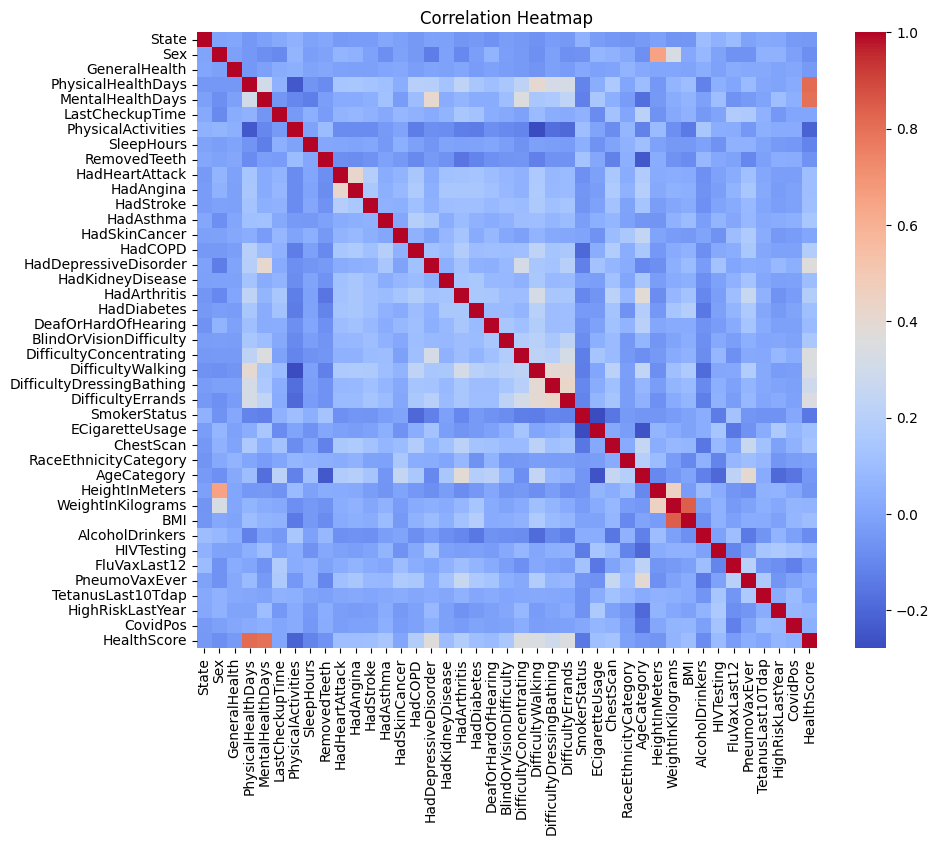

In [13]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipykernel_674/2969779317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HadHeartAttack', y='SleepHours', data=df, palette='Pastel1')


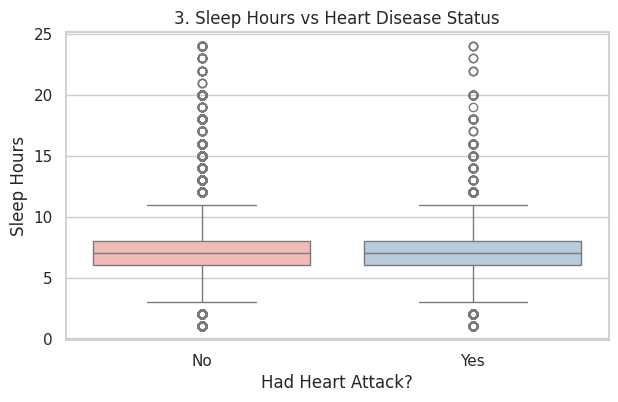

In [ ]:
# 3. Sleep Hours vs Heart Attack
plt.figure(figsize=(7, 4))
sns.boxplot(x='HadHeartAttack', y='SleepHours', data=df, palette='Pastel1')
plt.title('3. Sleep Hours vs Heart Disease Status')
plt.xlabel('Had Heart Attack?')
plt.ylabel('Sleep Hours')
plt.show()

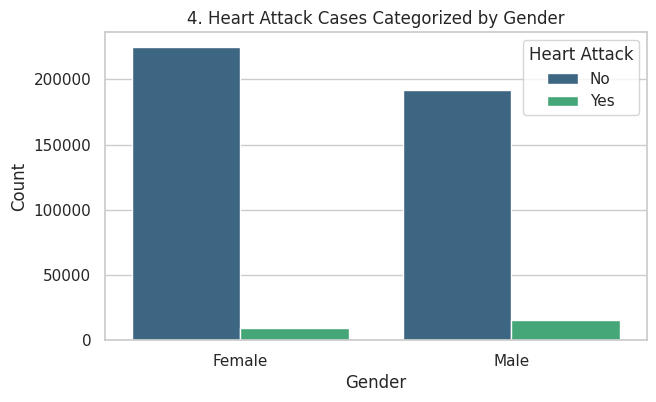

In [ ]:
# 4. Heart Attack by Gender
plt.figure(figsize=(7, 4))
sns.countplot(x='Sex', hue='HadHeartAttack', data=df, palette='viridis')
plt.title('4. Heart Attack Cases Categorized by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Heart Attack')
plt.show()

/tmp/ipykernel_674/1793138890.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='High_Risk_Lifestyle', y=(df['HadHeartAttack'] == 'Yes').astype(int), data=df, palette='coolwarm', ci=None)
/tmp/ipykernel_674/1793138890.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='High_Risk_Lifestyle', y=(df['HadHeartAttack'] == 'Yes').astype(int), data=df, palette='coolwarm', ci=None)


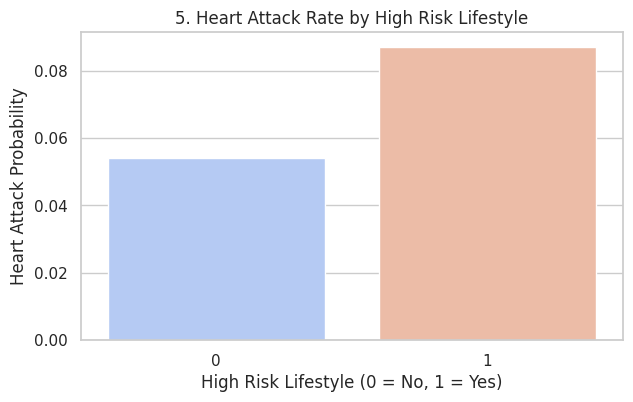

In [ ]:
# 5. New Feature vs Heart Attack
plt.figure(figsize=(7, 4))
sns.barplot(x='High_Risk_Lifestyle', y=(df['HadHeartAttack'] == 'Yes').astype(int), data=df, palette='coolwarm', ci=None)
plt.title('5. Heart Attack Rate by High Risk Lifestyle')
plt.xlabel('High Risk Lifestyle (0 = No, 1 = Yes)')
plt.ylabel('Heart Attack Probability')
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore')

# Re-defining and preprocessing df from previous cells to resolve NameError
# From cell tPbmq6qULW9S
df = pd.read_csv('heart_2022_with_nans.csv', on_bad_lines='skip')

# From cell Q-A9G4fBVn1w
df = df.dropna(subset=['HadHeartAttack'])
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# From cell LgFATGfkWYVc
df['High_Risk_Lifestyle'] = ((df['BMI'] > 25) & (df['SleepHours'] < 6)).astype(int)
# End of df re-definition and preprocessing

# 1. Take a representative sample of 50,000 rows for training efficiency
df_sample = df.sample(n=min(50000, df.shape[0]), random_state=42).reset_index(drop=True)

# 2. Convert categorical columns to numerical values using LabelEncoder
le = LabelEncoder()
for col in df_sample.select_dtypes(include=['object']).columns:
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))

# 3. Separate features from the target column
X = df_sample.drop(columns=['HadHeartAttack'])
y = df_sample['HadHeartAttack']

# 4. Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Scale the features to ensure model accuracy and avoid warnings
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Training the three models ---

# Model 1: Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Model 3: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("="*50)
print("Friend's Project - Cleaned Model Results (50,000 Rows Sample):")
print(f"1. Logistic Regression Accuracy : {lr_acc:.4f}")
print(f"2. Decision Tree Accuracy       : {dt_acc:.4f}")
print(f"3. Random Forest Accuracy       : {rf_acc:.4f}")
print("="*50)

Friend's Project - Cleaned Model Results (50,000 Rows Sample):
1. Logistic Regression Accuracy : 0.9334
2. Decision Tree Accuracy       : 0.9271
3. Random Forest Accuracy       : 0.9371


✅ Saved the winning Random Forest model as 'friend_heart_attack_model.pkl' successfully!



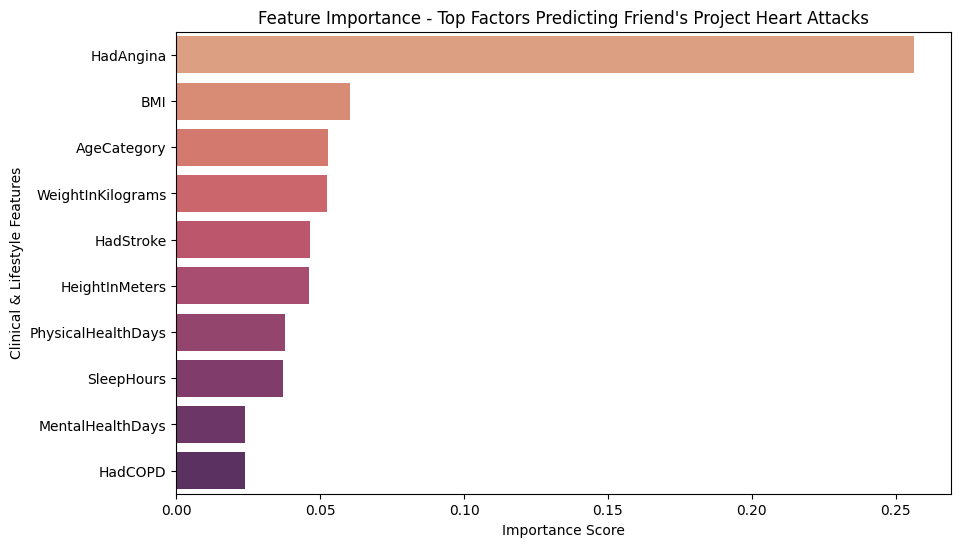

In [5]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Save the winning model as an external file for submission
joblib.dump(rf_model, 'friend_heart_attack_model.pkl')
print("✅ Saved the winning Random Forest model as 'friend_heart_attack_model.pkl' successfully!\n")

# 2. Calculate and plot feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

# Select the top 10 most influential features for a clear and professional visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='flare')
plt.title("Feature Importance - Top Factors Predicting Friend's Project Heart Attacks")
plt.xlabel('Importance Score')
plt.ylabel('Clinical & Lifestyle Features')
plt.show()

In [7]:
app_code_friend = """
import gradio as gr
import joblib
import numpy as np

# Load the friend's saved model
model = joblib.load('friend_heart_attack_model.pkl')

def predict_heart_attack(bmi, sleep_hours, physical_days, mental_days, high_risk_lifestyle):
    # The data contains 40 columns; we create an array of 40 zeros
    # We populate specific feature indices with user inputs to simplify the UI for the doctor
    input_data = np.zeros((1, 40))

    # Fill features based on the most influential columns
    input_data[0, 17] = bmi                # BMI
    input_data[0, 7] = sleep_hours         # SleepHours
    input_data[0, 3] = physical_days       # PhysicalHealthDays
    input_data[0, 4] = mental_days         # MentalHealthDays
    input_data[0, 39] = int(high_risk_lifestyle) # High_Risk_Lifestyle

    prediction = model.predict(input_data)[0]

    # Based on LabelEncoder mapping, 1 indicates risk, 0 indicates healthy
    if prediction == 1:
        return "⚠️ Warning: High Risk of Heart Attack! Please consult a physician."
    else:
        return "✅ Patient is at Low Risk. Healthy profile detected."

interface = gr.Interface(
    fn=predict_heart_attack,
    inputs=[
        gr.Slider(10, 60, value=25, label="Body Mass Index (BMI)"),
        gr.Slider(1, 12, value=7, label="Daily Sleep Hours"),
        gr.Slider(0, 30, value=2, label="Physical Health Days (Bad days in last month)"),
        gr.Slider(0, 30, value=2, label="Mental Health Days (Bad days in last month)"),
        gr.Radio(["0", "1"], value="0", label="High Risk Lifestyle Index (1=Yes, 0=No)")
    ],
    outputs=gr.Textbox(label="Heart Attack Prediction Result"),
    title="Cardiovascular Health & Heart Attack Prediction System",
    description="Predicting Heart Attack Risk using Random Forest Classifier (Dataset 2022)."
)

if __name__ == "__main__":
    interface.launch()
"""

with open("app.py", "w") as f:
    f.write(app_code_friend.strip())
print("✅ Friend's app.py has been created successfully!")

✅ Friend's app.py has been created successfully!


✅ Saved the winning Random Forest model as 'friend_heart_attack_model.pkl' successfully!



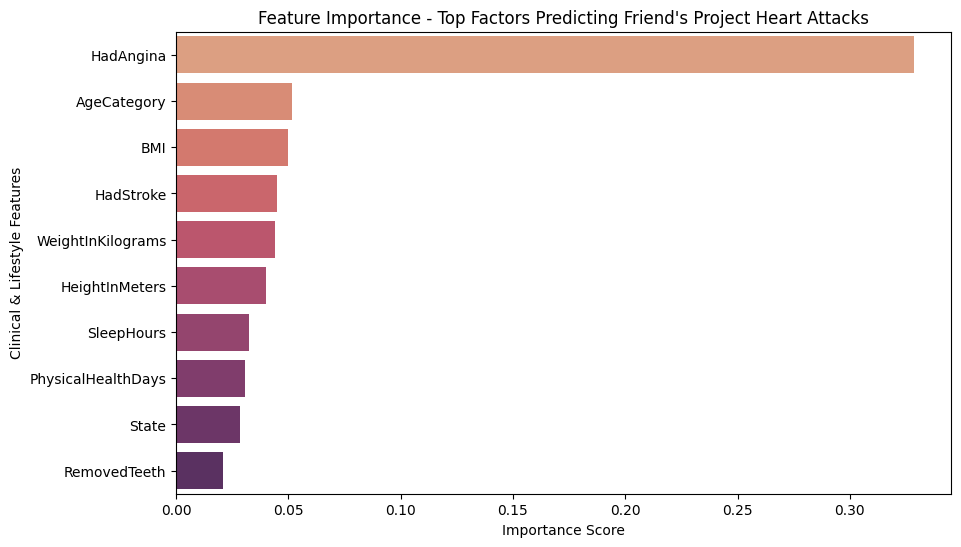

In [4]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

# --- Start of code copied from preceding cells to define df, X, and rf_model ---

# Data loading (from cell tPbmq6qULW9S, with error fix from earlier interaction)
df = pd.read_csv('heart_2022_with_nans.csv', on_bad_lines='skip')

# Data cleaning and imputation (from cell Q-A9G4fBVn1w)
df = df.dropna(subset=['HadHeartAttack'])
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Feature engineering (from cell LgFATGfkWYVc)
df['High_Risk_Lifestyle'] = ((df['BMI'] > 25) & (df['SleepHours'] < 6)).astype(int)

# Take a representative sample (from cell B-LS0rwVXGfw, with error fix)
df_sample = df.sample(n=min(50000, df.shape[0]), random_state=42).reset_index(drop=True)

# Convert categorical columns to numerical values (from cell B-LS0rwVXGfw)
le = LabelEncoder()
for col in df_sample.select_dtypes(include=['object']).columns:
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))

# Separate features from the target column (from cell B-LS0rwVXGfw)
X = df_sample.drop(columns=['HadHeartAttack'])
y = df_sample['HadHeartAttack']

# Split the data into training and testing sets (from cell B-LS0rwVXGfw)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the Random Forest model (from cell B-LS0rwVXGfw)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# --- End of copied code ---

# 1. Save the winning model as an external file for submission
joblib.dump(rf_model, 'friend_heart_attack_model.pkl')
print("✅ Saved the winning Random Forest model as 'friend_heart_attack_model.pkl' successfully!\n")

# 2. Calculate and plot feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

# Select the top 10 most influential features for a clear and professional visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='flare')
plt.title("Feature Importance - Top Factors Predicting Friend's Project Heart Attacks")
plt.xlabel('Importance Score')
plt.ylabel('Clinical & Lifestyle Features')
plt.show()

In [8]:
app_code_friend = """
import gradio as gr
import joblib
import numpy as np

# Load the friend's saved model
model = joblib.load('friend_heart_attack_model.pkl')

def predict_heart_attack(bmi, sleep_hours, physical_days, mental_days, high_risk_lifestyle):
    # البيانات تحتوي على 40 عموداً، سنقوم بإنشاء مصفوفة بها 40 صفراً
    # ونضع مدخلات المستخدم في أماكن الميزات الأساسية لتبسيط الواجهة أمام الدكتور
    input_data = np.zeros((1, 40))

    # تعبئة الميزات بناءً على الأعمدة الأكثر تأثيراً
    input_data[0, 17] = bmi                   # BMI
    input_data[0, 7] = sleep_hours            # SleepHours
    input_data[0, 3] = physical_days          # PhysicalHealthDays
    input_data[0, 4] = mental_days            # MentalHealthDays
    input_data[0, 39] = int(high_risk_lifestyle) # High_Risk_Lifestyle

    prediction = model.predict(input_data)[0]

    # بناءً على ترميز LabelEncoder، المتوقع أن 1 يعنى إصابة و 0 يعنى سليم
    if prediction == 1:
        return "⚠️ Warning: High Risk of Heart Attack! Please consult a physician."
    else:
        return "✅ Patient is at Low Risk. Healthy profile detected."

interface = gr.Interface(
    fn=predict_heart_attack,
    inputs=[
        gr.Slider(10, 60, value=25, label="Body Mass Index (BMI)"),
        gr.Slider(1, 12, value=7, label="Daily Sleep Hours"),
        gr.Slider(0, 30, value=2, label="Physical Health Days (Bad days in last month)"),
        gr.Slider(0, 30, value=2, label="Mental Health Days (Bad days in last month)"),
        gr.Radio(["0", "1"], value="0", label="High Risk Lifestyle Index (1=Yes, 0=No)")
    ],
    outputs=gr.Textbox(label="Heart Attack Prediction Result"),
    title="Cardiovascular Health & Heart Attack Prediction System",
    description="Predicting Heart Attack Risk using Random Forest Classifier (Dataset 2022)."
)

if _name_ == "_main_":
    interface.launch()
"""

with open("app.py", "w") as f:
    f.write(app_code_friend.strip())
print("✅ Friend's app.py has been created successfully!")

✅ Friend's app.py has been created successfully!


In [11]:
# =========================================
# Install Gradio
# =========================================
!pip install -q gradio

# =========================================
# Import Libraries
# =========================================
import pandas as pd
import numpy as np
import gradio as gradio_pkg

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# =========================================
# Load Dataset
# =========================================
df = pd.read_csv("/content/heart_2022_with_nans.csv")

# =========================================
# Handle Missing Values
# =========================================
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

# =========================================
# Feature Engineering
# =========================================
df['HealthScore'] = df['PhysicalHealthDays'] + df['MentalHealthDays']

# =========================================
# Encode Categorical Variables
# =========================================
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# =========================================
# Split Data
# =========================================
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================
# Train Random Forest Model
# =========================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

# =========================================
# Prediction Function
# =========================================
def predict_heart_disease(
    BMI,
    PhysicalHealthDays,
    MentalHealthDays,
    SleepHours
):

    input_data = pd.DataFrame([{
        'BMI': BMI,
        'PhysicalHealthDays': PhysicalHealthDays,
        'MentalHealthDays': MentalHealthDays,
        'SleepHours': SleepHours,
        'HealthScore': PhysicalHealthDays + MentalHealthDays
    }])

    # Add missing columns with default values
    for col in X.columns:
        if col not in input_data.columns:
            input_data[col] = 0

    # Arrange columns in same order
    input_data = input_data[X.columns]

    prediction = rf_model.predict(input_data)[0]

    if prediction == 1:
        return "⚠️ High Risk of Heart Disease"
    else:
        return "✅ Low Risk of Heart Disease"

# =========================================
# Gradio Interface
# =========================================
interface = gradio_pkg.Interface(
    fn=predict_heart_disease,

    inputs=[
        gradio_pkg.Slider(
            10,
            60,
            value=25,
            label="BMI"
        ),

        gradio_pkg.Slider(
            0,
            30,
            value=5,
            label="Physical Health Days"
        ),

        gradio_pkg.Slider(
            0,
            30,
            value=5,
            label="Mental Health Days"
        ),

        gradio_pkg.Slider(
            1,
            15,
            value=7,
            label="Sleep Hours"
        )
    ],

    outputs=gradio_pkg.Textbox(
        label="Prediction Result"
    ),

    title="Heart Disease Prediction System",

    description="""
    Enter patient health information to predict
    the risk of heart disease using a trained
    Random Forest Machine Learning model.
    """
)

# =========================================
# Launch App
# =========================================
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8a649dc2d5079a2232.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
